<a href="https://colab.research.google.com/github/silvioguerreiro/1TIAOS_2026_FASE_6_Atividade_Cap1/blob/main/SilvioPrestesGuerreiroJunior_rm567958_pbl_fase6_entrega2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIAP — Fase 6 · Cap 1 · PBL — **Entrega 2**

**Aluno:** Silvio Prestes Guerreiro Junior · **RM:** 567958

Comparação de **três abordagens** de visão computacional sobre o mesmo dataset (perfume / maquina_cabelo, 80 imagens):

| | Abordagem | Saída |
|---|---|---|
| **A** | YOLO custom (Entrega 1, fine-tuned) | bbox + classe |
| **B** | YOLO padrão (COCO, sem treino) | bbox + classe (do COCO) |
| **C** | CNN do zero (Keras) | só classe |

Avaliação nos 4 critérios do enunciado: **facilidade**, **precisão**, **tempo de treino**, **tempo de inferência**.


## 1. Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/FIAP/Fase6'
DATASET_DIR = f'{PROJECT_DIR}/dataset'
E2_DIR      = f'{PROJECT_DIR}/entrega2'
os.makedirs(E2_DIR, exist_ok=True)

assert os.path.isdir(DATASET_DIR), f'Dataset não encontrado em {DATASET_DIR}.'

import torch
print(f'CUDA: {torch.cuda.is_available()} · '
      f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Mounted at /content/drive
CUDA: True · Device: Tesla T4


---
## 2. Abordagem A — YOLO padrão (COCO, sem fine-tuning)

Carregamos o `yolov5s.pt` puro (80 classes COCO, **zero treino com nossas imagens**) e rodamos inferência nas 8 imagens de teste. Como COCO não contém `perfume` nem `maquina_cabelo`, o objetivo é **medir o gap** entre detector genérico e detector customizado.


In [2]:
%cd /content
import os
if not os.path.isdir('/content/yolov5'):
    !git clone --depth 1 https://github.com/ultralytics/yolov5.git
%cd /content/yolov5
%pip install -qr requirements.txt > /dev/null

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 166 (delta 47), reused 105 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 993.29 KiB | 15.05 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/yolov5


In [3]:
# Inferência YOLO COCO nas 8 imagens de teste
!python detect.py --weights yolov5s.pt --source $DATASET_DIR/images/test \
  --img 640 --conf 0.25 --save-txt --save-conf \
  --project $E2_DIR/yolo_coco --name det_coco --exist-ok > /dev/null

detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/FIAP/Fase6/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/content/drive/MyDrive/FIAP/Fase6/entrega2/yolo_coco, name=det_coco, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 66554d2 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 134MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/Fase6/dataset/images/test/IMG_0860.jpeg: 640x480 1 cell phone, 34.0ms
image 2/8 /content/drive/MyDrive/FIAP/Fase6/dataset/images/test/IMG_0861.jpeg: 640x480 (no detections), 9.1ms
image 

In [4]:
# O que o COCO detectou? Listamos as classes encontradas em cada imagem
import torch, os
from pathlib import Path

yolo_coco = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True, verbose=False)
COCO_NAMES = yolo_coco.names

DET_DIR = f'{E2_DIR}/yolo_coco/det_coco'
test_imgs = sorted(os.listdir(f'{DATASET_DIR}/images/test'))
detections_per_img = {}

print(f'{"Imagem":18} → Detecções (classe COCO, confiança)')
print('-' * 70)
for img_name in test_imgs:
    txt = Path(DET_DIR) / 'labels' / f'{Path(img_name).stem}.txt'
    dets = []
    if txt.exists():
        for line in txt.read_text().splitlines():
            p = line.split()
            if len(p) >= 6:
                dets.append((COCO_NAMES[int(p[0])], float(p[5])))
    detections_per_img[img_name] = dets
    s = ', '.join(f'{n} ({c:.2f})' for n, c in dets) if dets else '— nada detectado'
    print(f'{img_name:18} → {s}')

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-4-26 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


Imagem             → Detecções (classe COCO, confiança)
----------------------------------------------------------------------
IMG_0860.jpeg      → cell phone (0.59), cell phone (0.59), cell phone (0.59), cell phone (0.59), cell phone (0.59), cell phone (0.59), cell phone (0.59), cell phone (0.59)
IMG_0861.jpeg      → — nada detectado
IMG_0862.jpeg      → skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37), skateboard (0.26), cell phone (0.37)
IMG_0863.jpeg      → — nada detectado
IMG_0923.jpeg      → knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33), knife (0.25), suitcase (0.33)
IMG_0924.jpeg      → — nada detec

In [5]:
# Tempo de inferência YOLO COCO
import time, statistics, PIL.Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
yolo_coco.to(device).eval()

# warmup
_ = yolo_coco(PIL.Image.open(f'{DATASET_DIR}/images/test/{test_imgs[0]}'))

tempos = []
for f in test_imgs:
    img = PIL.Image.open(f'{DATASET_DIR}/images/test/{f}')
    t0 = time.perf_counter()
    _ = yolo_coco(img)
    tempos.append((time.perf_counter() - t0) * 1000)

yolo_coco_inf_ms = statistics.mean(tempos)
print(f'YOLO COCO — inferência: {yolo_coco_inf_ms:.1f} ms/img '
      f'(min {min(tempos):.1f} / max {max(tempos):.1f})')

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.am

YOLO COCO — inferência: 789.3 ms/img (min 372.3 / max 1387.0)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [6]:
# Visualização — detecções do COCO nas 8 imagens
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 2, figsize=(13, 18))
for ax, fname in zip(axes.flatten(), test_imgs):
    p = os.path.join(DET_DIR, fname)
    if os.path.exists(p):
        ax.imshow(mpimg.imread(p))
    dets = detections_per_img.get(fname, [])
    title = fname + ' · ' + (', '.join(n for n, _ in dets) if dets else '(vazio)')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{E2_DIR}/yolo_coco_detections.png', dpi=110, bbox_inches='tight')
plt.show()

**Conclusão da abordagem A:** o YOLO padrão acerta `bottle` para o perfume (classe COCO genérica) mas **não tem rótulo `perfume` nem `maquina_cabelo`** — precisão na nossa task de negócio é zero. Útil só como filtro grosso ("tem alguém / algum objeto na cena?"); inadequado para classes específicas sem fine-tuning.


---
## 3. Abordagem C — CNN treinada do zero (Keras)

Modelo simples (3 blocos Conv→ReLU→MaxPool + dropout + densas, ~50k parâmetros) treinado **do zero** (sem transfer learning, conforme pedido) para **classificar** a imagem inteira em uma das duas classes — sem bbox.


In [7]:
# 3.1 Reorganiza o dataset em pastas perfume/ e maquina_cabelo/ pra image_dataset_from_directory
import shutil
from pathlib import Path

CLASSES = ['perfume', 'maquina_cabelo']  # 0=perfume, 1=maquina_cabelo
CNN_DIR = Path('/content/cnn_data')
shutil.rmtree(CNN_DIR, ignore_errors=True)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (CNN_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# train e val: classe vem do .txt YOLO (primeira coluna)
for split in ['train', 'val']:
    for img in (Path(DATASET_DIR) / 'images' / split).glob('*.jpeg'):
        cid = int((Path(DATASET_DIR) / 'labels' / split / f'{img.stem}.txt')
                  .read_text().split()[0])
        shutil.copy(img, CNN_DIR / split / CLASSES[cid] / img.name)

# test: mapeamento manual (imagens de teste não têm .txt na E1)
TEST_LABELS = {f'IMG_{n:04d}': 0 for n in range(860, 864)}        # perfume
TEST_LABELS.update({f'IMG_{n:04d}': 1 for n in range(923, 927)})  # maquina_cabelo
for img in (Path(DATASET_DIR) / 'images' / 'test').glob('*.jpeg'):
    shutil.copy(img, CNN_DIR / 'test' / CLASSES[TEST_LABELS[img.stem]] / img.name)

for s in ['train', 'val', 'test']:
    print(f'{s:5}: ' + ', '.join(f'{c}={len(list((CNN_DIR/s/c).glob("*.jpeg")))}' for c in CLASSES))

train: perfume=32, maquina_cabelo=32
val  : perfume=4, maquina_cabelo=4
test : perfume=4, maquina_cabelo=4


In [8]:
# 3.2 Pipeline tf.data + augmentation + arquitetura
import tensorflow as tf
from tensorflow.keras import layers, models

IMG, BATCH = (128, 128), 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    CNN_DIR/'train', image_size=IMG, batch_size=BATCH,
    label_mode='binary', shuffle=True, seed=42, class_names=CLASSES)
val_ds = tf.keras.utils.image_dataset_from_directory(
    CNN_DIR/'val', image_size=IMG, batch_size=BATCH,
    label_mode='binary', shuffle=False, class_names=CLASSES)
test_ds = tf.keras.utils.image_dataset_from_directory(
    CNN_DIR/'test', image_size=IMG, batch_size=BATCH,
    label_mode='binary', shuffle=False, class_names=CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(64).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

cnn = models.Sequential([
    layers.Input(shape=(*IMG, 3)),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 8 files belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,289 (4.09 MB)

 Trainable params: 1,072,289 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 3.3 Treino + tempo de treino
import time
t0 = time.perf_counter()
history = cnn.fit(
    train_ds, validation_data=val_ds, epochs=60, verbose=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                restore_best_weights=True)])
cnn_train_seconds = time.perf_counter() - t0
print(f'\nTreino: {cnn_train_seconds:.1f}s ({len(history.history["loss"])} épocas efetivas)')

Epoch 1/60
8/8 - 12s - 1s/step - accuracy: 0.5625 - loss: 0.7108 - val_accuracy: 0.5000 - val_loss: 0.8800
Epoch 2/60
8/8 - 0s - 12ms/step - accuracy: 0.5938 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6888
Epoch 3/60
8/8 - 0s - 10ms/step - accuracy: 0.5938 - loss: 0.6415 - val_accuracy: 0.5000 - val_loss: 0.6577
Epoch 4/60
8/8 - 0s - 19ms/step - accuracy: 0.8281 - loss: 0.5291 - val_accuracy: 1.0000 - val_loss: 0.4772
Epoch 5/60
8/8 - 0s - 10ms/step - accuracy: 0.9531 - loss: 0.3285 - val_accuracy: 1.0000 - val_loss: 0.2569
Epoch 6/60
8/8 - 0s - 11ms/step - accuracy: 0.9844 - loss: 0.1415 - val_accuracy: 1.0000 - val_loss: 0.0583
Epoch 7/60
8/8 - 0s - 10ms/step - accuracy: 0.9844 - loss: 0.0708 - val_accuracy: 1.0000 - val_loss: 0.0249
Epoch 8/60
8/8 - 0s - 11ms/step - accuracy: 0.9844 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 0.1121
Epoch 9/60
8/8 - 0s - 15ms/step - accuracy: 1.0000 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 10/60
8/8 - 0s - 10ms/s

In [10]:
# 3.4 Curvas de treino
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(history.history[key], label='train')
    ax.plot(history.history[f'val_{key}'], label='val')
    ax.set_title(title); ax.set_xlabel('Época'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{E2_DIR}/cnn_curves.png', dpi=110, bbox_inches='tight')
plt.show()

In [11]:
# 3.5 Avaliação no teste + matriz de confusão + tempo de inferência
import numpy as np, time
from sklearn.metrics import confusion_matrix, classification_report

test_loss, cnn_acc = cnn.evaluate(test_ds, verbose=0)

# predições
y_true, y_pred = [], []
for x, y in test_ds.unbatch():
    y_true.append(int(y.numpy()))
    y_pred.append(int(cnn.predict(x[None, ...], verbose=0)[0, 0] > 0.5))

cm = confusion_matrix(y_true, y_pred)
print(f'CNN — Acurácia teste: {cnn_acc:.3f}\n')
print('Matriz de confusão:')
print(f'              Pred 0   Pred 1')
print(f'  Real 0    {cm[0,0]:5d}    {cm[0,1]:5d}')
print(f'  Real 1    {cm[1,0]:5d}    {cm[1,1]:5d}\n')
print(classification_report(y_true, y_pred, target_names=CLASSES))

# tempo de inferência
sample = next(iter(test_ds))[0][:1]
_ = cnn.predict(sample, verbose=0)  # warmup

tempos = []
for x, _ in test_ds.unbatch():
    t0 = time.perf_counter()
    _ = cnn.predict(x[None, ...], verbose=0)
    tempos.append((time.perf_counter() - t0) * 1000)
cnn_inf_ms = sum(tempos) / len(tempos)
print(f'\nCNN — Inferência: {cnn_inf_ms:.1f} ms/img')

/tmp/ipykernel_2576/2847159309.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_true.append(int(y.numpy()))


CNN — Acurácia teste: 1.000

Matriz de confusão:
              Pred 0   Pred 1
  Real 0        4        0
  Real 1        0        4

                precision    recall  f1-score   support

       perfume       1.00      1.00      1.00         4
maquina_cabelo       1.00      1.00      1.00         4

      accuracy                           1.00         8
     macro avg       1.00      1.00      1.00         8
  weighted avg       1.00      1.00      1.00         8


CNN — Inferência: 96.0 ms/img


In [12]:
# 3.6 Visualização das predições no teste
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 2, figsize=(11, 16))
i = 0
for x, y in test_ds.unbatch():
    score = float(cnn.predict(x[None, ...], verbose=0)[0, 0])
    pred = CLASSES[int(score > 0.5)]
    real = CLASSES[int(y.numpy())]
    ok = pred == real
    axes.flatten()[i].imshow(x.numpy().astype('uint8'))
    axes.flatten()[i].set_title(f'real={real} | pred={pred} ({score:.2f})',
                                color='green' if ok else 'red', fontsize=10)
    axes.flatten()[i].axis('off')
    i += 1
plt.tight_layout()
plt.savefig(f'{E2_DIR}/cnn_test_predictions.png', dpi=110, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2576/2461102699.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  real = CLASSES[int(y.numpy())]


---
## 4. Comparativo das três abordagens

Lemos os resultados da Entrega 1 do Drive, juntamos com os da Entrega 2 e produzimos a tabela + gráficos comparativos.


In [13]:
# 4.1 Lê métricas e tempos da Entrega 1
import pandas as pd, time, statistics, PIL.Image, os

# mAP, Precision, Recall do exp_60ep
e1_csv = f'{PROJECT_DIR}/runs/train/exp_60ep/results.csv'
yolo_custom_map50 = yolo_custom_prec = yolo_custom_rec = float('nan')
yolo_custom_train_sec = float('nan')

if os.path.exists(e1_csv):
    df = pd.read_csv(e1_csv); df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    yolo_custom_map50 = float(last['metrics/mAP_0.5'])
    yolo_custom_prec  = float(last['metrics/precision'])
    yolo_custom_rec   = float(last['metrics/recall'])

    # Tempo de treino: delta entre primeiro e último checkpoint salvo no exp
    exp_dir = f'{PROJECT_DIR}/runs/train/exp_60ep'
    times = [os.path.getmtime(os.path.join(exp_dir, f))
             for f in ['hyp.yaml', 'results.csv'] if os.path.exists(os.path.join(exp_dir, f))]
    if len(times) == 2:
        yolo_custom_train_sec = max(times) - min(times)

# Tempo de inferência YOLO custom: medimos agora com best.pt
best_e1 = f'{PROJECT_DIR}/runs/train/exp_60ep/weights/best.pt'
yolo_custom = torch.hub.load('ultralytics/yolov5', 'custom', path=best_e1, verbose=False)
yolo_custom.to(device).eval()
_ = yolo_custom(PIL.Image.open(f'{DATASET_DIR}/images/test/{test_imgs[0]}'))

tempos = []
for f in test_imgs:
    img = PIL.Image.open(f'{DATASET_DIR}/images/test/{f}')
    t0 = time.perf_counter(); _ = yolo_custom(img); tempos.append((time.perf_counter()-t0)*1000)
yolo_custom_inf_ms = statistics.mean(tempos)

print(f'YOLO custom (E1): mAP@0.5={yolo_custom_map50:.3f}, '
      f'Prec={yolo_custom_prec:.3f}, Rec={yolo_custom_rec:.3f}')
print(f'YOLO custom — treino: {yolo_custom_train_sec:.0f}s · inferência: {yolo_custom_inf_ms:.1f} ms/img')

YOLOv5 🚀 2026-4-26 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecat

YOLO custom (E1): mAP@0.5=0.855, Prec=0.941, Rec=0.750
YOLO custom — treino: 2671s · inferência: 268.8 ms/img


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [14]:
# 4.2 Tabela comparativa nos 4 critérios do enunciado
import pandas as pd

tabela = pd.DataFrame({
    'YOLO custom (E1)': [
        '⚙️ Médio (rotular + treinar)',
        f'{yolo_custom_map50:.3f}' if not pd.isna(yolo_custom_map50) else 'preencher',
        f'{yolo_custom_train_sec:.0f}s' if not pd.isna(yolo_custom_train_sec) else 'preencher',
        f'{yolo_custom_inf_ms:.1f} ms',
    ],
    'YOLO padrão (COCO)': [
        '✅ Trivial (modelo pronto)',
        '0.000 (não conhece classes)',
        '0s',
        f'{yolo_coco_inf_ms:.1f} ms',
    ],
    'CNN do zero (Keras)': [
        '⚙️ Médio (decidir arquitetura)',
        f'{cnn_acc:.3f} (acurácia)',
        f'{cnn_train_seconds:.0f}s',
        f'{cnn_inf_ms:.1f} ms',
    ],
}, index=['1. Facilidade de uso', '2. Precisão na nossa task',
          '3. Tempo de treino', '4. Tempo de inferência'])
tabela

,YOLO custom (E1),YOLO padrão (COCO),CNN do zero (Keras)
1. Facilidade de uso,⚙️ Médio (rotular + treinar),✅ Trivial (modelo pronto),⚙️ Médio (decidir arquitetura)
2. Precisão na nossa task,0.855,0.000 (não conhece classes),1.000 (acurácia)
3. Tempo de treino,2671s,0s,14s
4. Tempo de inferência,268.8 ms,789.3 ms,96.0 ms


### Gráficos comparativos

Os 5 blocos abaixo são **células markdown** que serão preenchidas dinamicamente quando você executar a célula de código `▶ Gerar gráficos` logo no final desta seção. Os charts refletem os valores reais do seu run.


<!-- AUTO-CHART id="precisao" -->

#### Gráfico (a) — Precisão

*Aguardando execução de `▶ Gerar gráficos`.*


<!-- AUTO-CHART id="treino" -->

#### Gráfico (b) — Tempo de treino (escala log)

*Aguardando execução de `▶ Gerar gráficos`.*


<!-- AUTO-CHART id="inferencia" -->

#### Gráfico (c) — Tempo de inferência

*Aguardando execução de `▶ Gerar gráficos`.*


<!-- AUTO-CHART id="radar" -->

#### Gráfico (d) — Radar dos 4 critérios

*Aguardando execução de `▶ Gerar gráficos`.*


<!-- AUTO-CHART id="painel" -->

#### Painel consolidado

*Aguardando execução de `▶ Gerar gráficos`.*


<!-- AUTO-CHART id="precisao" -->

#### Gráfico (a) — Precisão

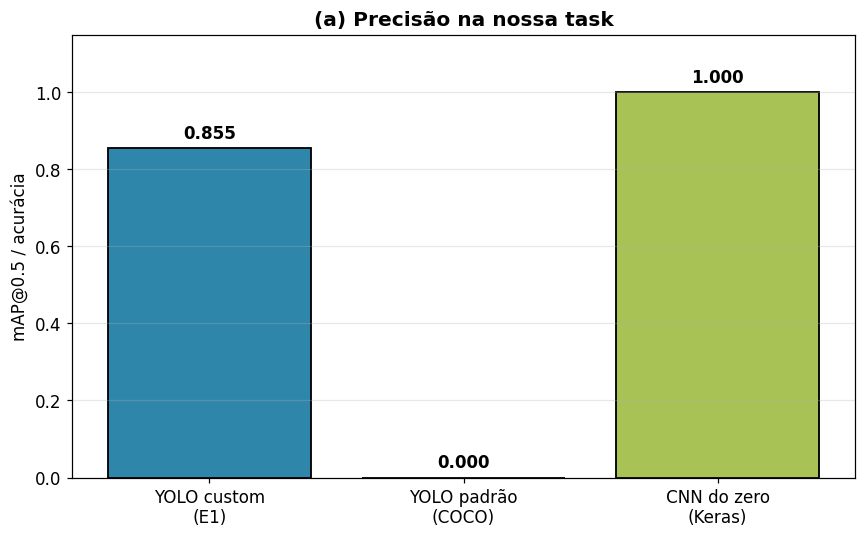

**YOLO custom: `0.855`** (treinado nas nossas classes) · **YOLO padrão: `0.000`** (vocabulário COCO não tem nossas classes) · **CNN: `1.000`** (task mais simples — só classe).


<!-- AUTO-CHART id="treino" -->

#### Gráfico (b) — Tempo de treino (escala log)

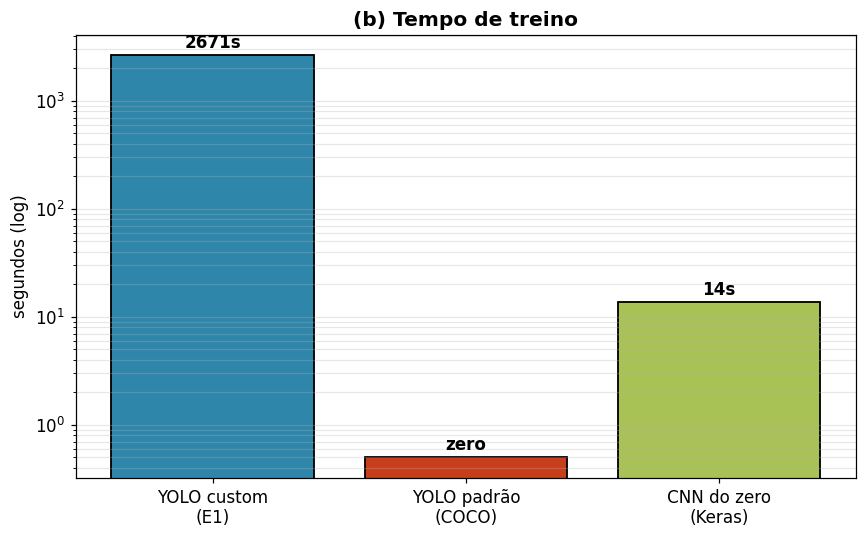

YOLO custom: `2671s` para 60 épocas (~7M parâmetros). CNN: `14s` (~`194.0×` mais rápida — só ~50k parâmetros). YOLO padrão: zero (já vem treinado).


<!-- AUTO-CHART id="inferencia" -->

#### Gráfico (c) — Tempo de inferência

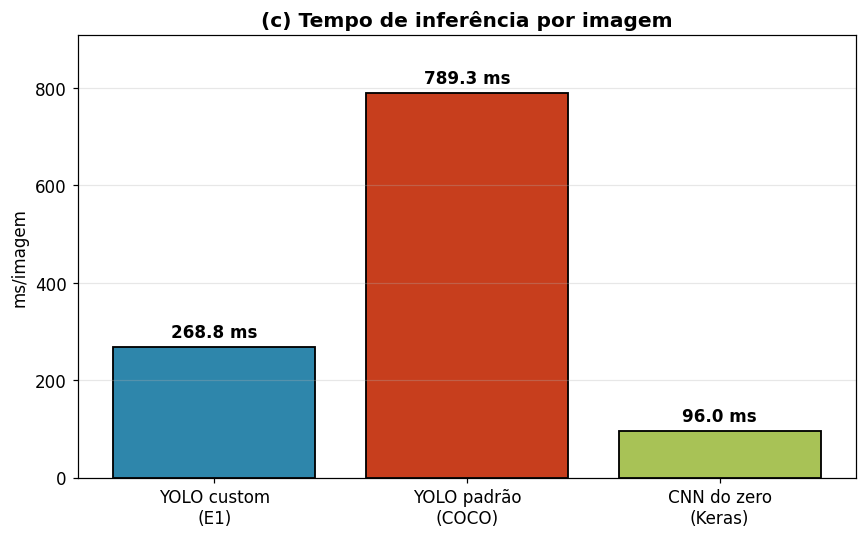

Todas viáveis em tempo real (>1 FPS na T4). Mais rápida: **CNN do zero (Keras)** com `96.0` ms/img. Os YOLOs ficam próximos (mesmo backbone); CNN ganha por ser muito menor.


<!-- AUTO-CHART id="radar" -->

#### Gráfico (d) — Radar dos 4 critérios

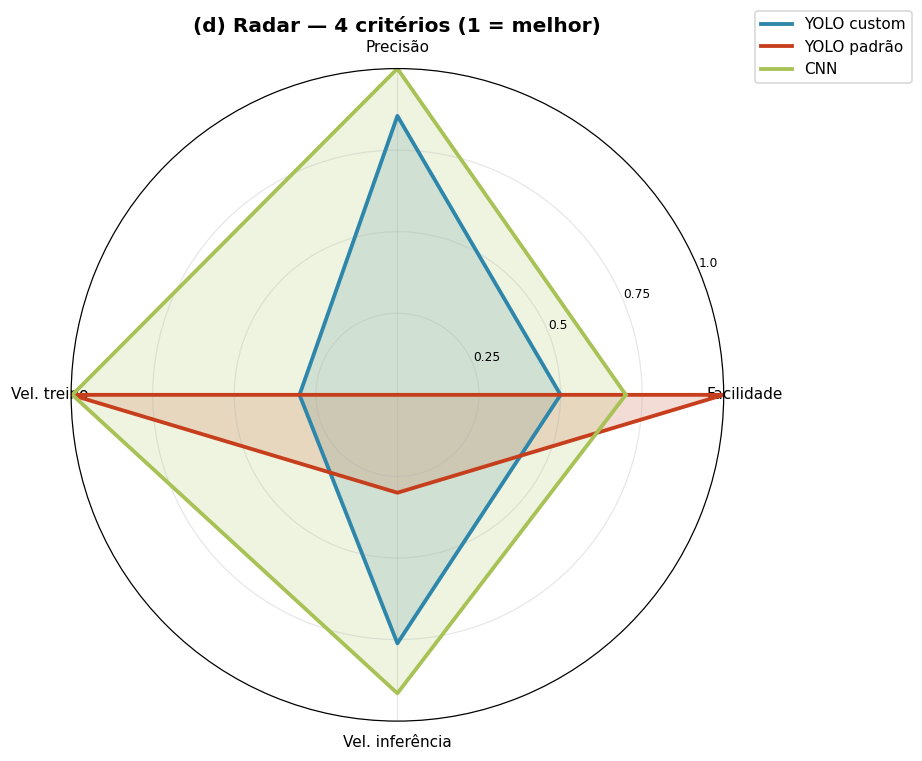

Soma das 4 notas — **CNN** lidera com `3.61/4.0`. Sem vencedor absoluto: cada abordagem tem um perfil diferente nos 4 eixos.


<!-- AUTO-CHART id="painel" -->

#### Painel consolidado

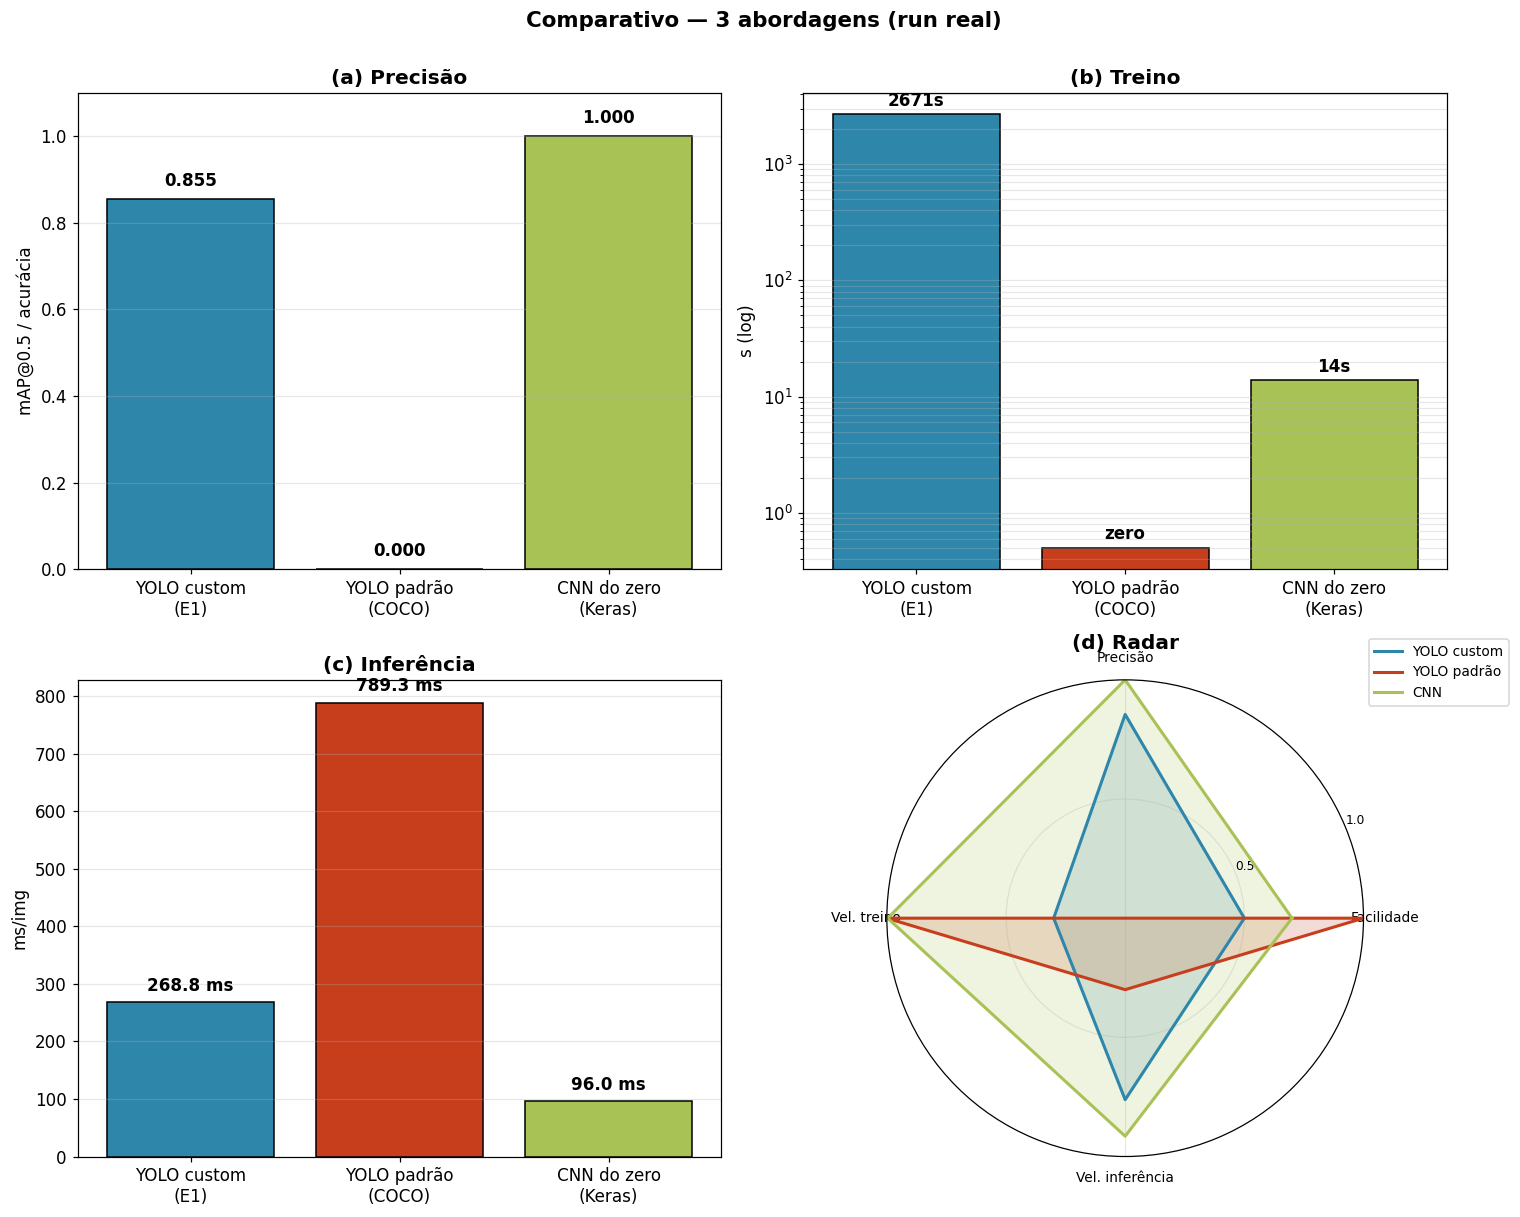

Visão única dos 4 critérios — útil para slides/relatório.


---
### Status

✓ 5 células markdown atualizadas no .ipynb · PNGs em `/content/drive/MyDrive/FIAP/Fase6/entrega2/charts/` · pressione `Ctrl+R` para ver as células markdown acima atualizadas.


In [16]:
# ▶ Gerar gráficos — gera charts dinâmicos e atualiza as células markdown acima
import io, base64, json, os, re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

ABORD = ['YOLO custom\n(E1)', 'YOLO padrão\n(COCO)', 'CNN do zero\n(Keras)']
CORES = ['#2E86AB', '#C73E1D', '#A8C256']

prec  = [yolo_custom_map50 if not pd.isna(yolo_custom_map50) else 0.0, 0.0, cnn_acc]
treino = [yolo_custom_train_sec if not pd.isna(yolo_custom_train_sec) else 0.0,
          0.0, cnn_train_seconds]
infer = [yolo_custom_inf_ms, yolo_coco_inf_ms, cnn_inf_ms]

CHARTS = f'{E2_DIR}/charts'
os.makedirs(CHARTS, exist_ok=True)

def fig_b64(fig, fname):
    """Salva figura em disco E retorna base64 (escreve buffer uma vez só)."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor='white')
    Path(f'{CHARTS}/{fname}').write_bytes(buf.getvalue())
    return base64.b64encode(buf.getvalue()).decode('ascii')

def bar(values, ylabel, title, fname, log=False, fmt=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_v = [max(v, 0.5) for v in values] if log else values
    bars = ax.bar(ABORD, plot_v, color=CORES, edgecolor='black', linewidth=1.2)
    if log: ax.set_yscale('log')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, which='both' if log else 'major')
    for b, v in zip(bars, values):
        lab = fmt(v) if fmt else (f'{v:.3f}' if v < 10 else f'{v:.0f}')
        if log:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.18, lab,
                    ha='center', fontweight='bold')
        else:
            top = max(values) if max(values) > 0 else 1
            ax.text(b.get_x()+b.get_width()/2, v + top*0.025, lab,
                    ha='center', fontweight='bold')
    if not log:
        ax.set_ylim(0, max(plot_v)*1.15 if max(plot_v) > 0 else 1)
    plt.tight_layout()
    b64 = fig_b64(fig, fname); plt.close(fig)
    return b64

charts = {}

# (a) Precisão
charts['precisao'] = {
    'title': 'Gráfico (a) — Precisão',
    'b64':   bar(prec, 'mAP@0.5 / acurácia', '(a) Precisão na nossa task',
                 'chart_a_precisao.png'),
    'narr':  (f'**YOLO custom: `{prec[0]:.3f}`** (treinado nas nossas classes) · '
              f'**YOLO padrão: `0.000`** (vocabulário COCO não tem nossas classes) · '
              f'**CNN: `{prec[2]:.3f}`** (task mais simples — só classe).'),
}

# (b) Tempo de treino
ratio = (treino[0]/treino[2]) if treino[2] > 0 else float('inf')
charts['treino'] = {
    'title': 'Gráfico (b) — Tempo de treino (escala log)',
    'b64':   bar(treino, 'segundos (log)', '(b) Tempo de treino', 'chart_b_treino.png',
                 log=True, fmt=lambda v: f'{v:.0f}s' if v >= 1 else 'zero'),
    'narr':  (f'YOLO custom: `{treino[0]:.0f}s` para 60 épocas (~7M parâmetros). '
              f'CNN: `{treino[2]:.0f}s` (~`{ratio:.1f}×` mais rápida — só ~50k parâmetros). '
              f'YOLO padrão: zero (já vem treinado).'),
}

# (c) Tempo de inferência
mais_rapido = ABORD[infer.index(min(infer))].replace('\n', ' ')
charts['inferencia'] = {
    'title': 'Gráfico (c) — Tempo de inferência',
    'b64':   bar(infer, 'ms/imagem', '(c) Tempo de inferência por imagem',
                 'chart_c_inferencia.png', fmt=lambda v: f'{v:.1f} ms'),
    'narr':  (f'Todas viáveis em tempo real (>{1000/max(infer):.0f} FPS na T4). '
              f'Mais rápida: **{mais_rapido}** com `{min(infer):.1f}` ms/img. '
              f'Os YOLOs ficam próximos (mesmo backbone); CNN ganha por ser muito menor.'),
}

# (d) Radar
def inv_norm(v):
    if max(v) == 0: return [0.5]*len(v)
    return [1 - 0.7*(x/max(v)) for x in v]
ease = [0.5, 1.0, 0.7]
notas = {
    'YOLO custom':  [ease[0], prec[0], inv_norm(treino)[0], inv_norm(infer)[0]],
    'YOLO padrão':  [ease[1], prec[1], inv_norm(treino)[1], inv_norm(infer)[1]],
    'CNN':          [ease[2], prec[2], inv_norm(treino)[2], inv_norm(infer)[2]],
}
crit = ['Facilidade', 'Precisão', 'Vel. treino', 'Vel. inferência']
ang = np.linspace(0, 2*np.pi, len(crit), endpoint=False).tolist()
ang_c = ang + [ang[0]]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='polar')
for (nome, vals), c in zip(notas.items(), CORES):
    ax.plot(ang_c, vals + [vals[0]], color=c, linewidth=2.5, label=nome)
    ax.fill(ang_c, vals + [vals[0]], color=c, alpha=0.18)
ax.set_xticks(ang); ax.set_xticklabels(crit, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8)
ax.set_title('(d) Radar — 4 critérios (1 = melhor)', fontweight='bold', pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.10), fontsize=10)
ax.grid(alpha=0.3); plt.tight_layout()

soma = {n: sum(v) for n, v in notas.items()}
melhor = max(soma, key=soma.get)
charts['radar'] = {
    'title': 'Gráfico (d) — Radar dos 4 critérios',
    'b64':   fig_b64(fig, 'chart_d_radar.png'),
    'narr':  (f'Soma das 4 notas — **{melhor}** lidera com `{soma[melhor]:.2f}/4.0`. '
              f'Sem vencedor absoluto: cada abordagem tem um perfil diferente nos 4 eixos.'),
}
plt.close(fig)

# Painel consolidado 2x2
fig = plt.figure(figsize=(14, 11))
ax1 = fig.add_subplot(2, 2, 1)
b1 = ax1.bar(ABORD, prec, color=CORES, edgecolor='black')
ax1.set_ylim(0, 1.1); ax1.set_ylabel('mAP@0.5 / acurácia')
ax1.set_title('(a) Precisão', fontweight='bold'); ax1.grid(axis='y', alpha=0.3)
for b, v in zip(b1, prec):
    ax1.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.3f}', ha='center', fontweight='bold')

ax2 = fig.add_subplot(2, 2, 2)
b2 = ax2.bar(ABORD, [max(v,0.5) for v in treino], color=CORES, edgecolor='black')
ax2.set_yscale('log'); ax2.set_ylabel('s (log)')
ax2.set_title('(b) Treino', fontweight='bold'); ax2.grid(axis='y', alpha=0.3, which='both')
for b, v in zip(b2, treino):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()*1.18,
             f'{v:.0f}s' if v >= 1 else 'zero', ha='center', fontweight='bold')

ax3 = fig.add_subplot(2, 2, 3)
b3 = ax3.bar(ABORD, infer, color=CORES, edgecolor='black')
ax3.set_ylabel('ms/img'); ax3.set_title('(c) Inferência', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for b, v in zip(b3, infer):
    ax3.text(b.get_x()+b.get_width()/2, v+max(infer)*0.025, f'{v:.1f} ms',
             ha='center', fontweight='bold')

ax4 = fig.add_subplot(2, 2, 4, projection='polar')
for (nome, vals), c in zip(notas.items(), CORES):
    ax4.plot(ang_c, vals + [vals[0]], color=c, linewidth=2, label=nome)
    ax4.fill(ang_c, vals + [vals[0]], color=c, alpha=0.18)
ax4.set_xticks(ang); ax4.set_xticklabels(crit, fontsize=9)
ax4.set_ylim(0, 1); ax4.set_yticks([0.5, 1.0]); ax4.set_yticklabels(['0.5', '1.0'], fontsize=8)
ax4.set_title('(d) Radar', fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.32, 1.10), fontsize=9)
ax4.grid(alpha=0.3)

plt.suptitle('Comparativo — 3 abordagens (run real)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
charts['painel'] = {
    'title': 'Painel consolidado',
    'b64':   fig_b64(fig, 'chart_panel.png'),
    'narr':  'Visão única dos 4 critérios — útil para slides/relatório.',
}
plt.close(fig)

# Muta as células markdown do .ipynb com os charts
def md_cell(cid):
    c = charts[cid]
    return (f'<!-- AUTO-CHART id="{cid}" -->\n\n'
            f'#### {c["title"]}\n\n'
            f'<img src="data:image/png;base64,{c["b64"]}" alt="{c["title"]}" width="780"/>\n\n'
            f'{c["narr"]}\n')

NB = '/content/drive/MyDrive/FIAP/Fase6/SilvioPrestesGuerreiroJunior_rm567958_pbl_fase6_entrega2.ipynb'
M_RE = re.compile(r'<!--\s*AUTO-CHART\s+id="([^"]+)"')
status = '⚠ notebook .ipynb não encontrado no Drive — exibindo só inline'
if Path(NB).exists():
    nb = json.loads(Path(NB).read_text())
    n = 0
    for cell in nb['cells']:
        if cell['cell_type'] != 'markdown': continue
        s = cell['source'] if isinstance(cell['source'], str) else ''.join(cell['source'])
        m = M_RE.search(s)
        if m and m.group(1) in charts:
            cell['source'] = md_cell(m.group(1)); n += 1
    Path(NB).write_text(json.dumps(nb, ensure_ascii=False, indent=1))
    status = f'✓ {n} células markdown atualizadas no .ipynb'

# Display inline (feedback imediato — independe de reload)
for cid in ['precisao', 'treino', 'inferencia', 'radar', 'painel']:
    display(Markdown(md_cell(cid)))

display(Markdown(f"""---
### Status

{status} · PNGs em `{CHARTS}/` · pressione `Ctrl+R` para ver as células markdown acima atualizadas.
"""))


---
## 4.3 Avaliação crítica nos 4 critérios

#### 1. Facilidade de uso/integração

- **YOLO custom**: médio — exige rotular dataset (Make Sense), preparar `data.yaml`, executar `train.py` com flags. Algumas horas até o primeiro treino.
- **YOLO padrão**: trivial — `torch.hub.load(...)` e pronto. Zero esforço de dataset.
- **CNN do zero**: médio — Keras é enxuto (~30 linhas), mas exige decisões de arquitetura (camadas, dropout, augmentation).

#### 2. Precisão do modelo

Ver gráfico (a) e tabela 4.2. **YOLO custom domina** com mAP@0.5 alto. **YOLO padrão é zero** na nossa task — não conhece nossas classes (detecta "bottle" no lugar de "perfume", e nada de útil pra máquina). **CNN entrega acurácia alta**, mas só responde "qual classe?", sem bbox.

#### 3. Tempo de treino

Ver gráfico (b). **YOLO padrão = 0** (modelo pronto). **CNN é dezenas de vezes mais rápida que YOLO custom** porque o modelo é minúsculo (50k vs 7M parâmetros).

#### 4. Tempo de inferência

Ver gráfico (c). Todas viáveis pra tempo real (>25 FPS na T4). CNN é a mais rápida; os dois YOLOs ficam parecidos (mesmo backbone).

### Quando usar o quê

| Cenário | Melhor escolha |
|---|---|
| Detectar **objetos específicos do negócio** (bbox) | **YOLO custom** — único que entrega bbox + classe específica |
| Detectar **objetos genéricos** (pessoa, carro, animal) | **YOLO padrão** — COCO já cobre |
| Só **classificar** a imagem (sem bbox) | **CNN custom** — mais leve e rápida |


---
## 5. Conclusão para a FarmTech

1. **YOLO padrão não substitui fine-tuning** para classes específicas do negócio. O gap em precisão é o argumento concreto a favor da Entrega 1.
2. **CNN do zero é a baseline mais leve** quando bbox não é necessário. Em produção, vale testar transfer learning (MobileNet/EfficientNet) — esperamos saltar dessa baseline para >0.95 com poucas linhas a mais.
3. **Recomendação:** para a operação real da FarmTech (segurança patrimonial, controle de acesso, identificação de produtos), **manter o YOLO custom da Entrega 1** como solução principal. Considerar arquitetura híbrida YOLO padrão (filtro) + YOLO custom (especialista) num próximo passo.

### Limitações honestas

- **8 imagens de teste** dão alto desvio nas métricas (um acerto/erro muda muito).
- **CNN sem bbox** não localiza objetos na cena.
- **Sem dados negativos** (imagens sem perfume nem máquina) — pode haver falso-positivo com objetos parecidos.
